CH.SC.U4CSE23248 Sriraam Vairavan R

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn

In [ ]:
D = {
    'Weather': ['Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy'],
    'Activity': ['Go Out', 'Go Out', 'Go Out', 'Stay In', 'Stay In', 'Stay In']
}

data = pd.DataFrame(D)
data.head()

,Weather,Activity
0,Sunny,Go Out
1,Sunny,Go Out
2,Sunny,Go Out
3,Rainy,Stay In
4,Rainy,Stay In


In [ ]:
data['Weather'] = data['Weather'].map({'Sunny': 1, 'Rainy': 0})
data['Activity'] = data['Activity'].map({'Go Out': 1, 'Stay In': 0})

In [ ]:
feature_cols = ['Weather']
X = data[feature_cols]
y = data['Activity']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

print("Train/Test shapes:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


Train/Test shapes:
(4, 1) (4,) (2, 1) (2,)


In [14]:
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
X_train: (4, 1) y_train: (4,)
X_test: (2, 1) y_test: (2,)


In [15]:
model = DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [16]:
y_pred = model.predict(X_test)
print("Predicted values:", y_pred)

Predicted values: [0 1]


In [17]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

Confusion Matrix:
 [[1 0]
 [0 1]]


In [18]:
accuracy_score = metrics.accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Accuracy Score: 1.0
Accuracy in Percentage: 100 %


# **MODEL TENDS TO OVERFIT DUE TO VERY LIMITED SIZE OF DATASET ( 6 TUPLES)**

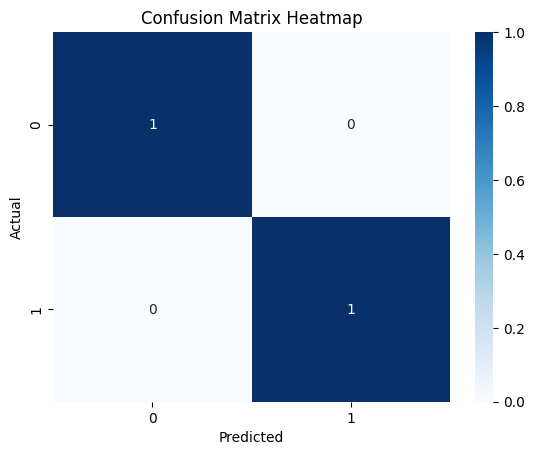

In [19]:
conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, cmap="Blues", fmt='g')
plt.title("Confusion Matrix Heatmap")
plt.show()